In [1]:
import numpy as np
import torch
import torch.nn as nn
from typing import Iterable

from utils import onehot
from automatons import PatternMatchingAutomaton, Automaton
from architectures import RecursiveNeuralNetworkFromScratch

In [2]:
pattern = [0, 1, 1, 0]
patternon = PatternMatchingAutomaton(pattern)
end_of_sequence_token = patternon.tokens
end_of_sequence_token

2

In [3]:
def pattern_matching_data_generator():
  data = onehot([*list(patternon.generator), end_of_sequence_token], patternon.tokens+1)
  return data[:-1], data[1:]

In [4]:
def sample_callback(model, epoch, **kwargs):
	Wxh, Whh, Why, bh, by = model.weights.values()
	x = pattern_matching_data_generator()[0][0]
	ixes = []
	h = torch.zeros([model.hidden_size,])

	while True:
		h = torch.tanh(Wxh @ x +  Whh @ h + bh)
		p = torch.nn.functional.softmax(Why @ h + by, dim=0)
		ix = np.random.choice(range(patternon.tokens+1), p=p.detach().numpy().ravel())
		x = torch.zeros((patternon.tokens+1,))
		x[ix] = 1
		ixes.append(ix)
		if ix == end_of_sequence_token:
			break
	print(epoch,"\t", ixes[-4-1:], ixes)

In [5]:
RNN = RecursiveNeuralNetworkFromScratch(tokens = patternon.tokens+1, hidden_size=5) # account for the end of sequence token

In [6]:
history = list(RNN.fit(
	pattern_matching_data_generator,
	epochs=3000,
	callbacks=[sample_callback],
))

2999 	 [0, 2] [0, 2]
2998 	 [0, 1, 1, 0, 2] [0, 1, 0, 1, 1, 0, 2]
2997 	 [1, 1, 0, 0, 2] [0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 2]
2996 	 [1, 1, 0, 0, 2] [0, 1, 0, 1, 0, 1, 1, 0, 0, 2]
2995 	 [1, 0, 0, 0, 2] [1, 0, 1, 0, 0, 0, 2]
2994 	 [1, 1, 0, 0, 2] [0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 2]
2993 	 [0, 0, 0, 0, 2] [1, 1, 0, 0, 0, 0, 0, 0, 2]
2992 	 [2] [2]
2991 	 [0, 0, 0, 0, 2] [1, 0, 0, 0, 0, 2]
2990 	 [1, 0, 1, 0, 2] [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 2]
2989 	 [1, 0, 1, 1, 2] [1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 2]
2988 	 [1, 0, 1, 0, 2] [1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 2]
2987 	 [2] [2]
2986 	 [1, 1, 1, 0, 2] [1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 2]
2985 	 [0, 1, 1, 0, 2] [0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 2]
2984 	 [1, 0, 0, 1, 2]

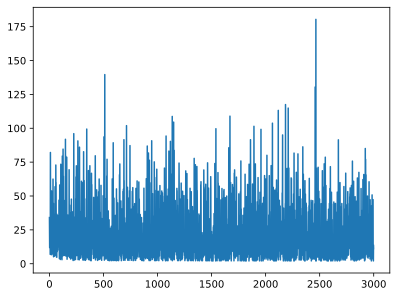

In [7]:
import matplotlib.pyplot as plt
plt.plot(history) #?